<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/best_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Best model

1. config:
- deep net with BN
- default adam
- batch size 64
- medium augmentation

2. config:
- deep net with BN with leakyRelu(0.1)
- default adam
- batch size 64
- medium augmentation

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:03<00:00, 44.5MB/s]


torch.Size([1, 3, 32, 32])


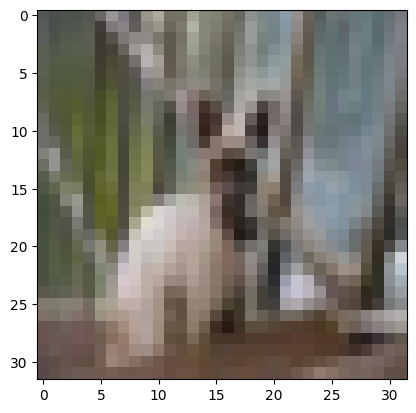

tensor([3])
cat
torch.Size([1, 3, 32, 32])


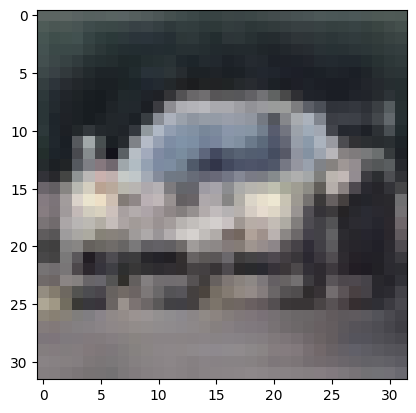

tensor([1])
car
torch.Size([1, 3, 32, 32])


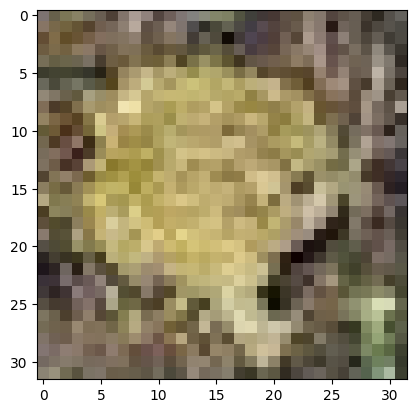

tensor([6])
frog
torch.Size([1, 3, 32, 32])


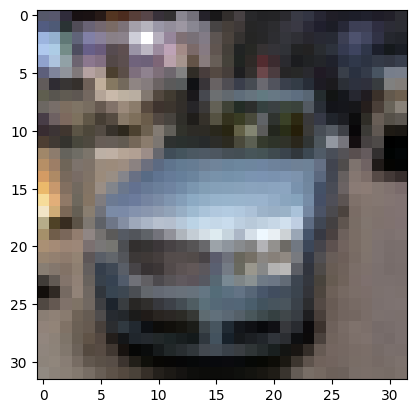

tensor([1])
car
torch.Size([1, 3, 32, 32])


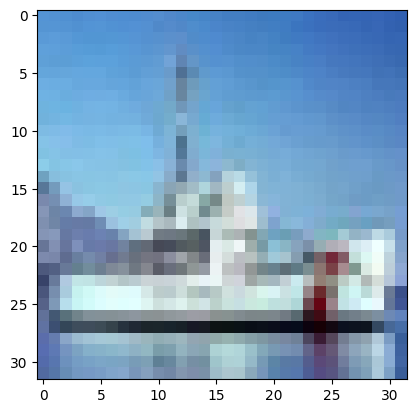

tensor([8])
ship
torch.Size([1, 3, 32, 32])


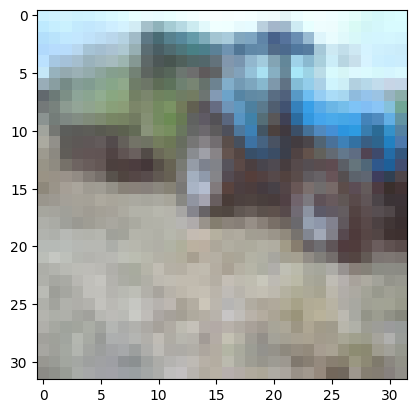

tensor([9])
truck
torch.Size([1, 3, 32, 32])


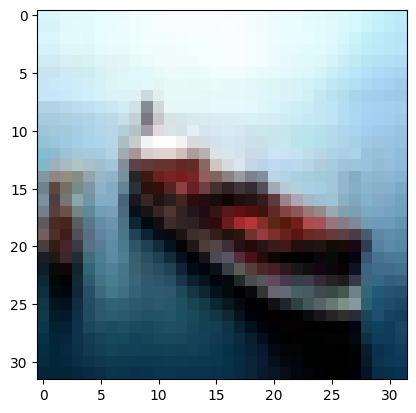

tensor([8])
ship
torch.Size([1, 3, 32, 32])


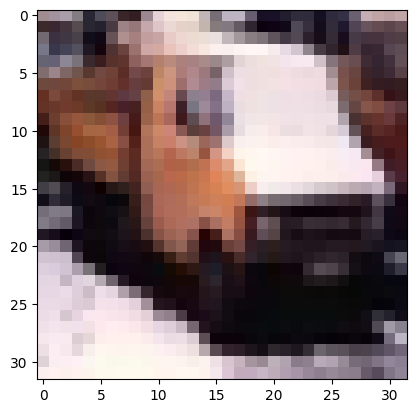

tensor([9])
truck
torch.Size([1, 3, 32, 32])


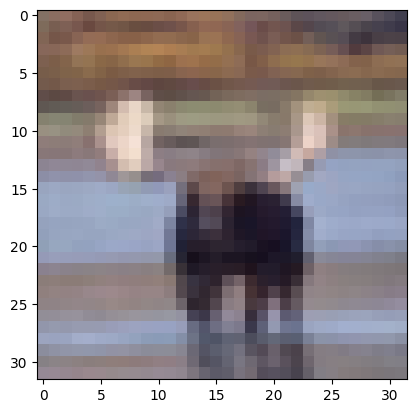

tensor([4])
deer
torch.Size([1, 3, 32, 32])


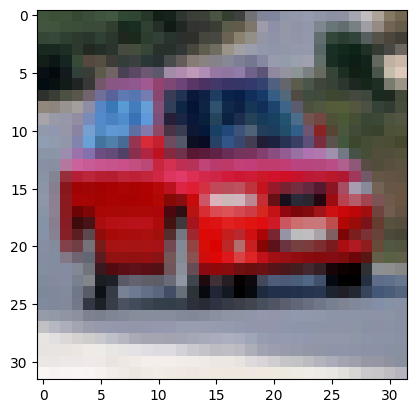

tensor([1])
car
torch.Size([1, 3, 32, 32])


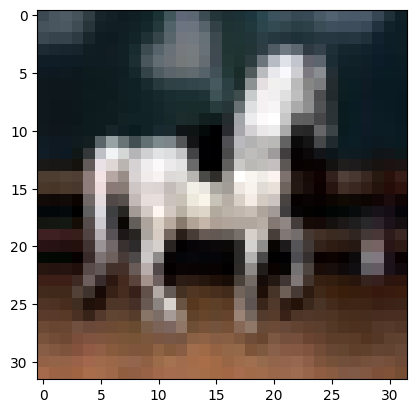

tensor([7])
horse


In [ ]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [ ]:
from torch.nn import Sequential, Linear, ReLU, Softmax, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d

# should reach 70% val acuraccy in circa 14 epochs

def build_model(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 64),
        ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference

model, model_inference = build_model()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.1091, 0.0935, 0.0986, 0.0974, 0.1063, 0.0992, 0.0982, 0.0962, 0.0978,
         0.1039]], grad_fn=<SoftmaxBackward0>)
plane


In [ ]:
medium_transform = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])

In [ ]:
dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=medium_transform)
trainset_aug, _ = torch.utils.data.random_split(dataset_aug, [45000, 5000], generator=torch.Generator().manual_seed(42))

In [ ]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Training loss at step 0: 2.3079419136047363
Training loss at step 100: 2.141981601715088
Training loss at step 200: 2.290830135345459
Training loss at step 300: 1.8157247304916382
Training loss at step 400: 1.7208138704299927
Training loss at step 500: 1.5746333599090576
Training loss at step 600: 1.668969750404358
Training loss at step 700: 1.7885884046554565
Training loss at step 800: 1.652286171913147
Training loss at step 900: 1.487378478050232
Training loss at step 1000: 1.650404453277588
Training loss at step 1100: 1.6611309051513672
Training loss at step 1200: 1.2175832986831665
Training loss at step 1300: 1.515695333480835
Training loss at step 1400: 1.4694106578826904
Val loss at epoch 0: 1.5569600041504879
Val acc at epoch 0: 0.4428
Training loss at step 0: 1.3463348150253296
Training loss at step 100: 1.4704136848449707
Training loss at step 200: 1.7570143938064575
Training loss at step 300: 1.640971064567566
Training loss at step 400: 1.419432282447815

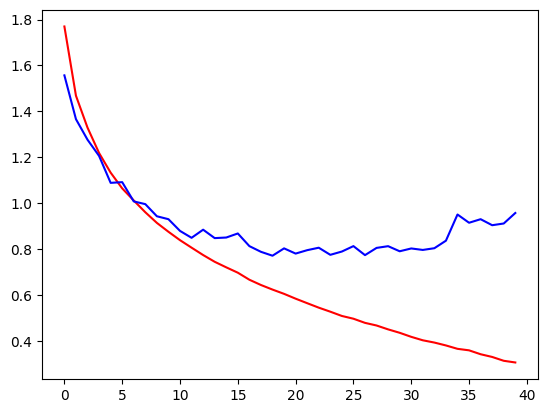

In [ ]:
batch_size = 64

dataloader_train = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

model, model_inference = build_model()

model.to(device)
model_inference.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epoch_train_losses = []
epoch_val_losses = []
epoch_val_accs = []

for e in range(120):
  train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, verbose=False)

  print("Val loss at epoch {}: {}".format(e, val_loss))
  print("Val acc at epoch {}: {}".format(e, val_acc))

  torch.save(model.state_dict(), "{:03d}.pth".format(e))
  epoch_train_losses.append(train_loss)
  epoch_val_losses.append(val_loss)
  epoch_val_accs.append(val_acc)

plt.plot(epoch_train_losses, c='r')
plt.plot(epoch_val_losses, c='b')
plt.show()

In [ ]:
print(f"Last training loss: {epoch_train_losses[-1]}\nLast validation loss: {epoch_val_losses[-1]}\nLast validation accuracy: {epoch_val_acss[-1]}")
print(f"Best training loss: {np.min(epoch_train_losses)} ({np.argmin(epoch_train_losses)})\nBest validation loss: {np.min(epoch_val_losses)} ({np.argmin(epoch_val_losses)})\nBest validation accuracy: {np.max(epoch_val_acss)} ({np.argmax(epoch_val_accs)})")

In [ ]:
# @title Dumping losses and val accuracy into json
import json

baseline_results = {
    'train_losses': epoch_train_losses,
    'val_losses': epoch_val_losses,
    'val_accuracies': epoch_val_accs
}

with open('best_results.json', 'w') as f:
    json.dump(baseline_results, f)

print("best results saved to baseline_results.json")

Baseline results saved to baseline_results.json
